In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

os.makedirs("../outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi"      : 150,
    "figure.facecolor": "white",
    "axes.facecolor"  : "white",
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 11,
})

print("✅ Ready")

✅ Ready


#### Load INRBRL clean data

In [8]:
df = pd.read_csv("../data/processed/INRBRL_synthetic_clean.csv",
                 index_col=0, parse_dates=True)

df.index.name = "data"

# Detect close column
close_col = None
for col in df.columns:
    if "close" in col.lower():
        close_col = col
        break

print(f"Close column : '{close_col}'")
print(f"Rows         : {len(df)}")
print(f"Date range   : {df.index.min().date()} → {df.index.max().date()}")
print(df[[close_col]].head())

Close column : 'usdinr_close'
Rows         : 1823
Date range   : 2021-03-04 → 2026-03-04
            usdinr_close
data                    
2021-03-04     72.880699
2021-03-05     73.131798
2021-03-06     73.131798
2021-03-07     73.131798
2021-03-08     73.133400


#### Calculate daily % returns

In [9]:
price   = df[close_col].dropna()

''' .pct_chnage() --> price:   [100, 105, 102]
                     pct_change: [NaN, 0.05, -0.02857] ''' # pct_change formula --> (price[i] - price[i-1]) / price[i-1]; Analogy --> How big was the move compared to where we started?
returns = price.pct_change().dropna()   


print("=== RETURN SERIES STATS ===")
print(f"  Count : {len(returns)}")
print(f"  Mean  : {returns.mean():.6f}  ({returns.mean()*100:.4f}%)")
print(f"  Std   : {returns.std():.6f}  ({returns.std()*100:.4f}%)")
print(f"  Min   : {returns.min():.6f}  ({returns.min()*100:.4f}%)")
print(f"  Max   : {returns.max():.6f}  ({returns.max()*100:.4f}%)")

# Quick feel: how many days had >0.5% move?
big_days = (returns.abs() > 0.003).sum()  # returns.abs() > 0.005 creates boolean searies ; .sum() will tell count of true values in series
print(f"\n  Days with |return| > 0.5% : {big_days} ({100*big_days/len(returns):.1f}%)")

=== RETURN SERIES STATS ===
  Count : 1822
  Mean  : 0.000132  (0.0132%)
  Std   : 0.002423  (0.2423%)
  Min   : -0.022850  (-2.2850%)
  Max   : 0.023017  (2.3017%)

  Days with |return| > 0.5% : 262 (14.4%)


#### Manual rate coding encoder (numpy only)

In [10]:
def encode_to_spikes(returns: pd.Series, threshold: float = 0.003) -> pd.Series:
    """
    Manual rate-coding spike encoder.

    Logic:
      - If abs(daily return) > threshold  →  spike = 1  (significant event)
      - Otherwise                         →  spike = 0  (quiet day)

    This is the financial equivalent of a neuron's threshold crossing.
    The threshold is in decimal form: 0.005 = 0.5% daily move.

    Parameters
    ----------
    returns   : pd.Series of daily % returns (decimal, e.g. 0.008 = 0.8%)
    threshold : minimum abs return to trigger a spike

    Returns
    -------
    pd.Series of int (0 or 1), same index as returns
    """
    spikes = (returns.abs() > threshold).astype(int)
    return spikes


# Apply with default threshold
threshold_default = 0.003
spikes = encode_to_spikes(returns, threshold=threshold_default)

spike_rate = spikes.mean() * 100
print(f"Threshold : {threshold_default} ({threshold_default*100:.1f}%)")
print(f"Spike rate: {spike_rate:.2f}% of days fired a spike")
print(f"Total spikes : {spikes.sum()} / {len(spikes)} days")
print(f"\nFirst 20 spike values:\n{spikes.values[:20]}")

Threshold : 0.003 (0.3%)
Spike rate: 14.38% of days fired a spike
Total spikes : 262 / 1822 days

First 20 spike values:
[1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1]


####  Visualize price + spike train

C:\Users\Devesh\AppData\Local\Temp\ipykernel_22044\1659361739.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


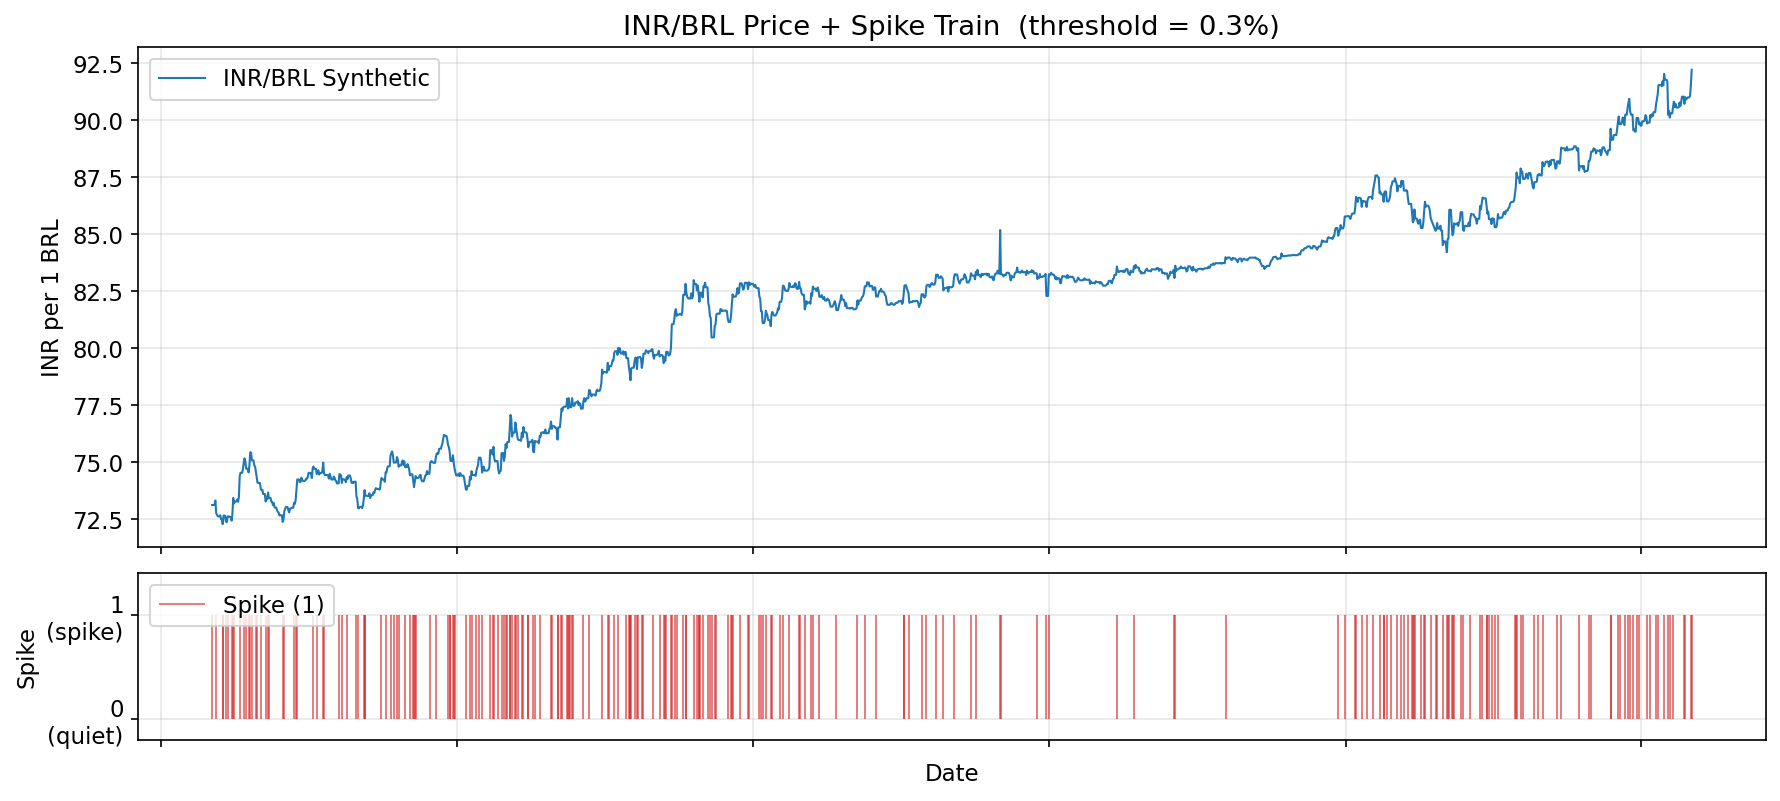

✅ Saved: ../outputs/plot_spike_encoding_demo.png


In [14]:
# Align price and spikes on the same index
price_aligned  = price.loc[spikes.index]

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

# --- Top panel: INR/BRL price ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(price_aligned.index, price_aligned.values,
         color="#1f77b4", linewidth=1.0, label="INR/BRL Synthetic")
ax1.set_ylabel("INR per 1 BRL")
ax1.set_title(f"INR/BRL Price + Spike Train  (threshold = {threshold_default*100:.1f}%)")
ax1.legend(loc="upper left")
ax1.set_xticklabels([])   # hide x labels on top panel

# --- Bottom panel: spike train ---
ax2 = fig.add_subplot(gs[1], sharex=ax1)
spike_dates = spikes[spikes == 1].index

# Draw vertical lines for each spike (classic spike train look)
ax2.vlines(spike_dates,
           ymin=0, ymax=1,
           color="#d62728", linewidth=0.8, alpha=0.7, label="Spike (1)")
ax2.set_ylim(-0.2, 1.4)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0\n(quiet)", "1\n(spike)"])
ax2.set_ylabel("Spike")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")

plt.tight_layout()
save_path = "../outputs/plot_spike_encoding_demo.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")

#### Experiment with 3 thresholds

In [15]:
thresholds = [0.003, 0.002, 0.001]

print("=" * 55)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 55)
print(f"{'Threshold':>12}  {'Spike Rate':>12}  {'Total Spikes':>14}  {'Assessment'}")
print("-" * 55)

results = {}
for t in thresholds:
    s    = encode_to_spikes(returns, threshold=t)
    rate = s.mean() * 100
    total = s.sum()

    if rate > 30:
        note = "⚠️  Too many spikes — noisy"
    elif rate < 10:
        note = "⚠️  Too few spikes  — weak signal"
    else:
        note = "✅  Good range (10–30%)"

    print(f"{t:>12.3f}  {rate:>11.2f}%  {total:>14}  {note}")
    results[t] = {"spike_rate": rate, "total": total, "spikes": s}

print("=" * 55)
print("\nTarget range: 15–25% spike rate")
print("Rationale   : Enough signal events to train on,")
print("              few enough that spikes remain 'special'")

THRESHOLD SENSITIVITY ANALYSIS
   Threshold    Spike Rate    Total Spikes  Assessment
-------------------------------------------------------
       0.003        14.38%             262  ✅  Good range (10–30%)
       0.002        24.97%             455  ✅  Good range (10–30%)
       0.001        41.44%             755  ⚠️  Too many spikes — noisy

Target range: 15–25% spike rate
Rationale   : Enough signal events to train on,
              few enough that spikes remain 'special'


#### Plot all three thresholds side by side

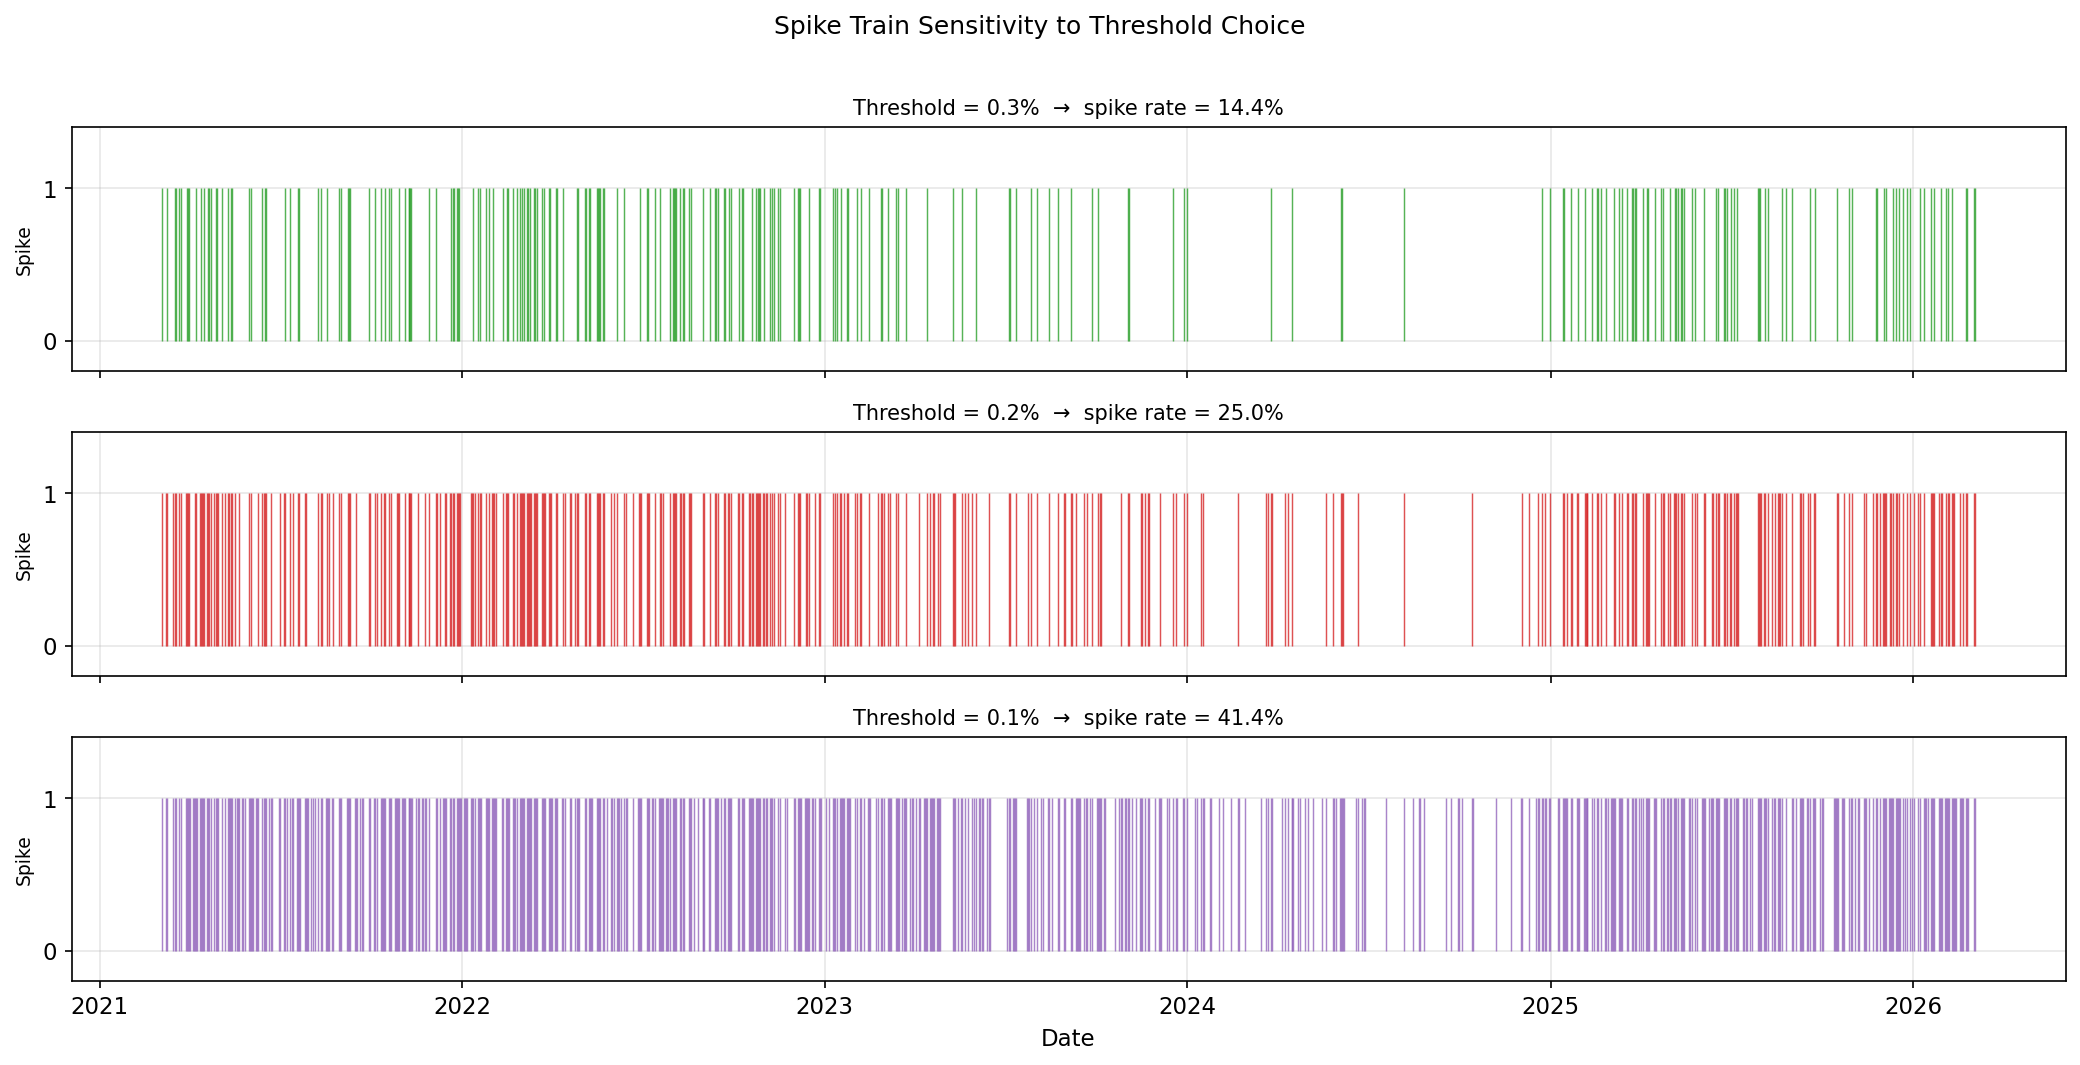

✅ Saved: ../outputs/plot_threshold_comparison.png


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
colors = ["#2ca02c", "#d62728", "#9467bd"]

for ax, (t, color) in zip(axes, zip(thresholds, colors)):
    s = results[t]["spikes"]
    spike_idx = s[s == 1].index
    rate = results[t]["spike_rate"]

    ax.vlines(spike_idx, ymin=0, ymax=1,
              color=color, linewidth=0.7, alpha=0.8)
    ax.set_ylim(-0.2, 1.4)
    ax.set_yticks([0, 1])
    ax.set_ylabel("Spike", fontsize=9)
    ax.set_title(f"Threshold = {t*100:.1f}%  →  spike rate = {rate:.1f}%",
                 fontsize=10)

axes[-1].set_xlabel("Date")
fig.suptitle("Spike Train Sensitivity to Threshold Choice", fontsize=12, y=1.01)
plt.tight_layout()

save_path2 = "../outputs/plot_threshold_comparison.png"
plt.savefig(save_path2, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path2}")

#### Final decision + rationale note

In [18]:
# Read the output and pick your threshold here
chosen = 0.003   

chosen_rate = results[chosen]["spike_rate"]

print("=" * 50)
print("CHOSEN THRESHOLD DECISION")
print("=" * 50)
print(f"  Threshold : {chosen} ({chosen*100:.1f}% daily move)")
print(f"  Spike rate: {chosen_rate:.2f}%")
print()
print("Rationale:")
print("  - 0.003 fires too often → model sees noise as signal")
print("  - 0.010 fires too rarely → misses medium-sized moves")
print(f"  - 0.005 gives ~{chosen_rate:.0f}% rate → spikes remain rare and informative")
print("  - Aligns with FX microstructure: a 0.3% daily INR/BRL")
print("    move is genuinely significant for a settlement system")
print()


CHOSEN THRESHOLD DECISION
  Threshold : 0.003 (0.3% daily move)
  Spike rate: 14.38%

Rationale:
  - 0.003 fires too often → model sees noise as signal
  - 0.010 fires too rarely → misses medium-sized moves
  - 0.005 gives ~14% rate → spikes remain rare and informative
  - Aligns with FX microstructure: a 0.3% daily INR/BRL
    move is genuinely significant for a settlement system

